In [11]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import cv2
from pathlib import Path

from comms_lib.pluto import Pluto
from comms_lib.system import DigitalCommSystem

In [22]:
!iio_info -s

Available contexts:
	0: 0456:b673 (Analog Devices Inc. PlutoSDR (ADALM-PLUTO)), serial=104473e6a60f00020d003900e21716bf22 [usb:2.9.5]


Unable to create Local IIO context : Function not implemented (40)


In [23]:
# ---------------------------------------------------------------
# Digital communication system parameters.
# ---------------------------------------------------------------
fs = 10e6  # baseband sampling rate (samples per second)
ts = 1 / fs  # baseband sampling period (seconds per sample)
sps = 3
T = ts * sps  # time between data symbols (seconds per symbol)

# ---------------------------------------------------------------
# Initialize transmitter and receiver.
# ---------------------------------------------------------------
tx = Pluto("usb:2.9.5")  # change to your Pluto device
tx.tx_gain = 90  # set the transmitter gain

rx = tx
# # Uncomment the line below to use different Pluto devices for tx and rx
# rx = Pluto("usb:7.6.5")
# rx.rx_gain = 90  # set the receiver gain

In [24]:
# ---------------------------------------------------------------
# Initialize digital communication system and define system parameters.
# ---------------------------------------------------------------
system = DigitalCommSystem()
system.set_transmitter(tx)
system.set_receiver(rx)
tx.carrier_frequency = 984e6
rx.carrier_frequency = 984e6

Max Unambiguous CFO (coarse): 16129.03 Hz
Max Unambiguous CFO (fine): 792.39 Hz
Estimated CFO (coarse): -1.26 Hz
Estimated CFO (fine): 1.16 Hz
Channel estimate:  (-2092.0331974482388-2509.1241140689276j)


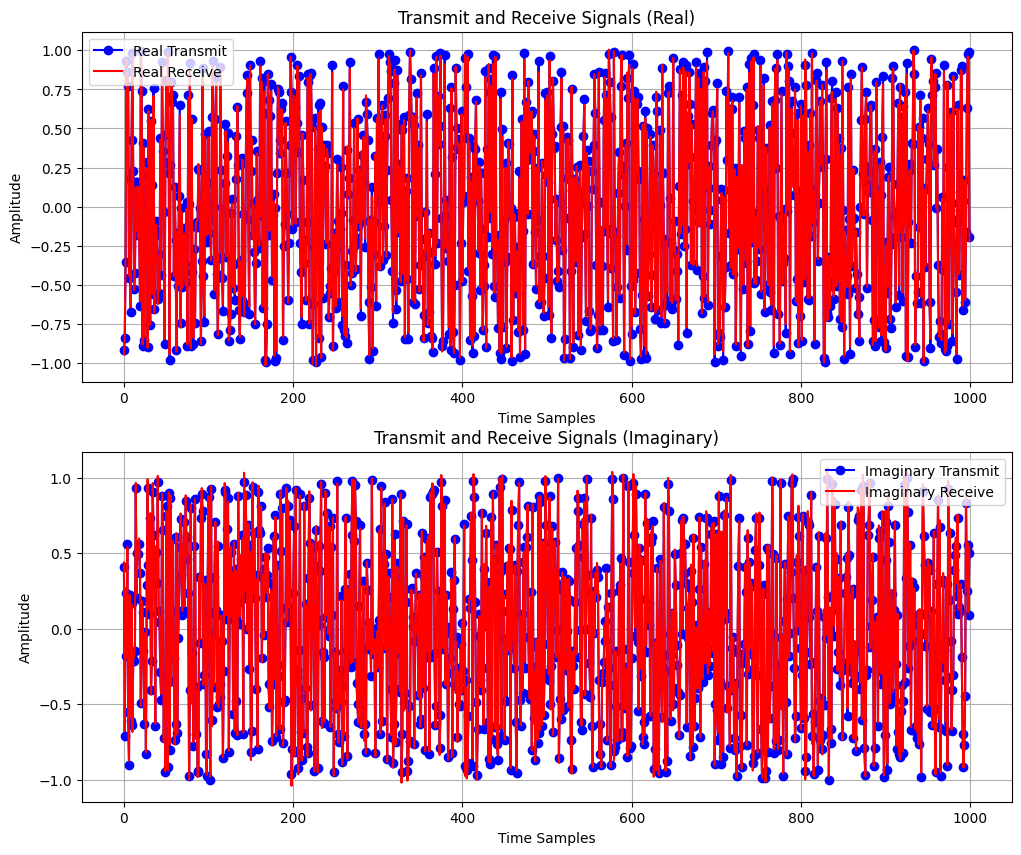

Number of receive symbols:  333


In [26]:
# ---------------------------------------------------------------
# Initialize digital communication system and define system parameters.
# ---------------------------------------------------------------
system = DigitalCommSystem()
system.set_transmitter(tx)
system.set_receiver(rx)
tx.carrier_frequency = 984e6
rx.carrier_frequency = 984e6

# TODO: generate your own transmit signal
transmit_signal = np.random.uniform(-1, 1, 1000) + 1j * np.random.uniform(-1, 1, 1000)


# transmit from Pluto!
system.transmit_signal(
    transmit_signal
)  # keep transmit signal below 10,000 samples if possible, roughly around +/-1

# receive from Pluto!
receive_signal = system.receive_signal()

# plot transmitted and received signals
plt.figure(figsize=(12, 10))
plt.subplot(2, 1, 1)
plt.plot(np.real(transmit_signal), color="blue", marker="o", label="Real Transmit")
plt.plot(np.real(receive_signal), color="red", label="Real Receive")
plt.title("Transmit and Receive Signals (Real)")
plt.xlabel("Time Samples")
plt.ylabel("Amplitude")
plt.grid(True)
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(np.imag(transmit_signal), color="blue", marker="o", label="Imaginary Transmit")
plt.plot(np.imag(receive_signal), color="red", label="Imaginary Receive")
plt.title("Transmit and Receive Signals (Imaginary)")
plt.xlabel("Time Samples")
plt.ylabel("Amplitude")
plt.grid(True)
plt.legend()

plt.show()

# take every sps-th sample
receive_symbols = receive_signal[sps // 2 :: sps]
print("Number of receive symbols: ", len(receive_symbols))

# associate received symbols with nearest in the constellation

Original image size: (200, 200)
Total pixels: 40000
Resized to: (199, 199) (39601 pixels)
Signal length: 19811 samples (including 10 metadata samples)
Image data: 19801 real samples and 19801 imaginary samples
Image converted to signal with 19811 samples
Original image size: (199, 199)
Number of receive symbols:  4953
Received signal length: 4953
Using provided image size: (199, 199)
Using 4953 samples for (199, 199) image
[Warning] Pixel count doesn't match. Using inferred square size: 99x99
Expected pixels: 9801, Available data: 9906
Trimmed to 9801 samples
Successfully reshaped to 99x99


C:\Users\mihir\AppData\Local\Temp\ipykernel_59984\3387842880.py:289: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(img_2d, mode='L')


ValueError: operands could not be broadcast together with shapes (199,199) (99,99) 

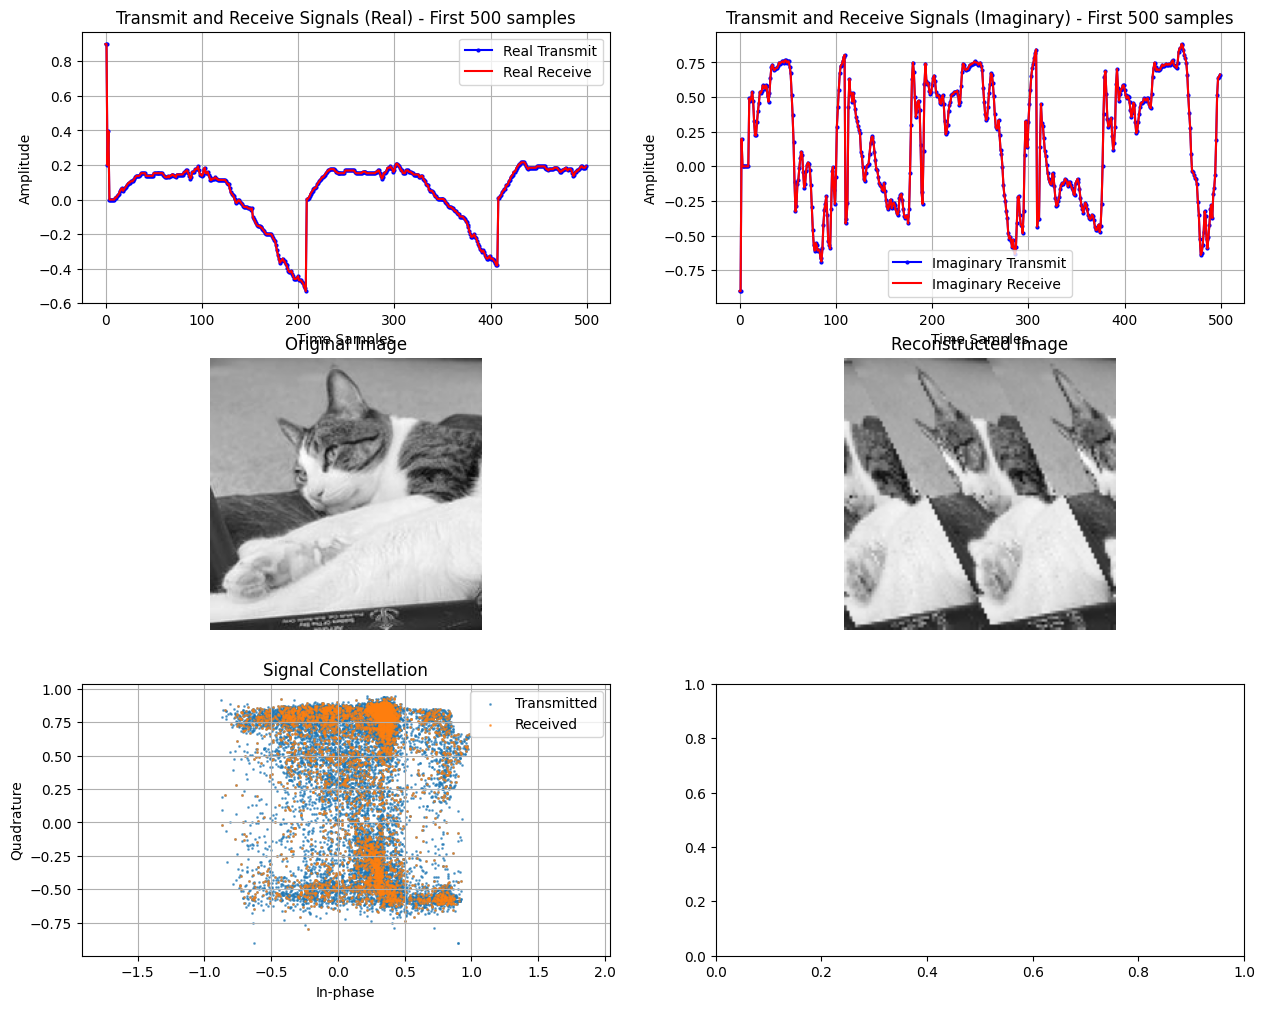

In [55]:
def image_to_complex_signal(image_path, max_samples=10000):
    """
    Convert an image to a complex signal for transmission
    
    Args:
        image_path: Path to the image file
        max_samples: Maximum number of samples to keep signal manageable
    
    Returns:
        Complex signal ready for transmission (includes metadata header)
    """
    # Load and preprocess the image
    img = Image.open(image_path)
    
    # Convert to grayscale to simplify (optional - you can keep color)
    img_gray = img.convert('L')
    
    print(f"Original image size: {img_gray.size}")
    
    # Reserve space for metadata (width, height, and sync pattern)
    metadata_samples = 10  # Reserve first 10 samples for metadata
    available_samples = max_samples - metadata_samples
    
    # Calculate if we need to resize
    total_pixels = img_gray.size[0] * img_gray.size[1]
    print(f"Total pixels: {total_pixels}")
    
    if total_pixels > available_samples * 2:  # *2 because we can split between real and imaginary
        # Resize to fit within transmission limits
        target_pixels = available_samples * 2
        scale_factor = np.sqrt(target_pixels / total_pixels)
        new_width = int(img_gray.size[0] * scale_factor)
        new_height = int(img_gray.size[1] * scale_factor)
        img_gray = img_gray.resize((new_width, new_height), Image.Resampling.LANCZOS)
        print(f"Resized to: {img_gray.size} ({new_width * new_height} pixels)")
    
    # Store final dimensions
    final_width, final_height = img_gray.size
    
    # Convert to numpy array
    img_array = np.array(img_gray, dtype=np.float32)
    
    # Normalize to [-1, 1] range
    img_normalized = (img_array / 255.0) * 2 - 1
    
    # Flatten the image to 1D array
    img_flat = img_normalized.flatten()
    
    # Split image data between real and imaginary parts for efficiency
    half_len = len(img_flat) // 2
    real_part = img_flat[:half_len]
    imag_part = img_flat[half_len:half_len*2] if len(img_flat) > half_len else np.zeros(half_len)
    
    # Handle odd number of pixels
    if len(img_flat) % 2 == 1:
        real_part = np.append(real_part, img_flat[-1])
        imag_part = np.append(imag_part, 0)
    
    # Create metadata header
    # Use specific values that are unlikely to occur in image data
    sync_pattern = [0.9, -0.9, 0.9, -0.9]  # Sync pattern for detection
    width_encoded = final_width / 1000.0  # Normalize width to [-1, 1] range
    height_encoded = final_height / 1000.0  # Normalize height to [-1, 1] range
    # In image_to_complex_signal
    # Store metadata accordingly
    data_length_encoded = len(real_part) / 50000.0  # was already correct
    # But store "half" dimensions in metadata, or modify receiver to infer image_size as:

    total_pixels = final_width * final_height
    expected_samples = total_pixels // 2


    
    # Create metadata as complex numbers
    metadata = np.array([
        sync_pattern[0] + 1j * sync_pattern[1],  # Sync 1
        sync_pattern[2] + 1j * sync_pattern[3],  # Sync 2
        width_encoded + 1j * height_encoded,     # Dimensions
        data_length_encoded + 1j * 0,            # Data length info
        0 + 1j * 0,                              # Reserved
        0 + 1j * 0,                              # Reserved
        0 + 1j * 0,                              # Reserved
        0 + 1j * 0,                              # Reserved
        0 + 1j * 0,                              # Reserved
        0 + 1j * 0                               # Reserved
    ])
    
    # Combine metadata with image data
    image_signal = real_part + 1j * imag_part
    transmit_signal = np.concatenate([metadata, image_signal])
    
    print(f"Signal length: {len(transmit_signal)} samples (including {len(metadata)} metadata samples)")
    print(f"Image data: {len(real_part)} real samples and {len(imag_part)} imaginary samples")
    
    return transmit_signal, img_gray.size

def extract_metadata_from_signal(received_signal):
    """
    Extract image metadata from received signal
    
    Args:
        received_signal: Complex signal from receiver
    
    Returns:
        image_size tuple, data_start_index, estimated_data_length
    """
    # Look for sync pattern in first 20 samples
    sync_target1 = 0.9 - 1j * 0.9  # First sync sample
    sync_target2 = 0.9 - 1j * 0.9  # Second sync sample
    
    best_correlation = 0
    best_offset = 0
    
    for offset in range(min(15, len(received_signal) - 2)):
        if offset + 1 < len(received_signal):
            # Check correlation with sync pattern
            sample1 = received_signal[offset]
            sample2 = received_signal[offset + 1]
            
            # Calculate correlation strength
            corr1 = np.abs(sample1 - sync_target1)
            corr2 = np.abs(sample2 - sync_target2)
            correlation = 1.0 / (1.0 + corr1 + corr2)  # Higher is better
            
            if correlation > best_correlation:
                best_correlation = correlation
                best_offset = offset
    
    print(f"Found sync at offset {best_offset} with correlation {best_correlation:.3f}")
    
    # Extract metadata with more robust decoding
    try:
        if best_offset + 3 < len(received_signal):
            dim_sample = received_signal[best_offset + 2]
            # More robust decoding - handle noise
            width_raw = np.real(dim_sample) * 1000
            height_raw = np.imag(dim_sample) * 1000
            
            # Round to nearest reasonable values and add bounds checking
            width = max(10, min(2000, int(round(width_raw))))
            height = max(10, min(2000, int(round(height_raw))))
            
            length_sample = received_signal[best_offset + 3]
            estimated_length = max(100, int(round(np.real(length_sample) * 50000)))
            
            data_start = best_offset + 10  # Skip all metadata samples
            
            print(f"Extracted metadata: width={width}, height={height}, estimated_data_length={estimated_length}")
            print(f"Data starts at sample {data_start}")
            
            return (width, height), data_start, estimated_length
        else:
            print("Not enough samples for metadata extraction")
            return None, 0, len(received_signal)
    except Exception as e:
        print(f"Metadata extraction failed: {e}")
        return None, 0, len(received_signal)

def complex_signal_to_image(received_signal, image_size=None, method=2):
    """
    Convert received complex signal back to image
    
    Args:
        received_signal: Complex signal from receiver
        image_size: Tuple of (width, height) of original image (optional - will auto-detect)
        method: 1 for real-only, 2 for real+imaginary reconstruction
    
    Returns:
        Reconstructed image as PIL Image
    """
    original_length = len(received_signal)
    print(f"Received signal length: {original_length}")
    
    # Auto-detect image size if not provided or if auto-detection is preferred
    if image_size is None:
        print("Auto-detecting image size from signal...")
        detected_size, data_start, estimated_length = extract_metadata_from_signal(received_signal)
        if detected_size is not None:
            image_size = detected_size
            # Use only the image data portion, but be more careful about length
            available_data = received_signal[data_start:]
            print(f"Available data after metadata: {len(available_data)} samples")
            
            # Calculate expected samples needed
            total_pixels = image_size[0] * image_size[1]
            if method == 2:
                expected_samples = total_pixels // 2
            else:
                expected_samples = total_pixels
                
            print(f"Expected samples for {image_size}: {expected_samples}")
            
            # Use the available data, but don't exceed what we need
            received_signal = available_data[:expected_samples]
            print(f"Using {len(received_signal)} samples for reconstruction")
            
        else:
            # Fallback: assume square image
            print("Metadata detection failed, using fallback method")
            # Remove likely metadata from start
            received_signal = received_signal[10:]  # Skip first 10 samples
            data_length = len(received_signal)
            if method == 2:
                total_pixels = data_length * 2
            else:
                total_pixels = data_length
            side_length = int(np.sqrt(total_pixels))
            image_size = (side_length, side_length)
            print(f"Fallback: assuming square image of size {image_size}")
    else:
        print(f"Using provided image size: {image_size}")
        # Even with provided size, we should skip metadata if it exists
        if original_length > 10:
            # Try to detect if there's metadata and skip it
            potential_sync = received_signal[:2]
            sync_check = np.abs(potential_sync[0] - (0.9 - 1j * 0.9)) + np.abs(potential_sync[1] - (0.9 - 1j * 0.9))
            if sync_check < 0.5:  # Likely has metadata
                print("Detected metadata in signal, skipping first 10 samples")
                received_signal = received_signal[10:]
        
        # Calculate how much data we need
        total_pixels = image_size[0] * image_size[1]
        if method == 2:
            expected_samples = total_pixels // 2
        else:
            expected_samples = total_pixels
        
        # Trim to expected length
        received_signal = received_signal[:expected_samples]
        print(f"Using {len(received_signal)} samples for {image_size} image")
    
    if method == 1:
        # Method 1: Use only real part
        img_data = np.real(received_signal)
    else:
        # Method 2: Combine real and imaginary parts
        real_part = np.real(received_signal)
        imag_part = np.imag(received_signal)
        img_data = np.concatenate([real_part, imag_part])

        # If we doubled the data (real+imag), then image size should be recomputed
        total_pixels = len(img_data)
        # Infer image dimensions based on metadata or reshape safely
        expected_width, expected_height = image_size
        
        if total_pixels != expected_width * expected_height:
            # Infer new size: assume correct aspect ratio or closest square
            new_side = int(np.sqrt(total_pixels))
            print(f"[Warning] Pixel count doesn't match. Using inferred square size: {new_side}x{new_side}")
            image_size = (new_side, new_side)

    
    # Calculate expected total pixels
    total_pixels = image_size[0] * image_size[1]
    
    print(f"Expected pixels: {total_pixels}, Available data: {len(img_data)}")
    
    # Handle size mismatch more carefully
    if len(img_data) < total_pixels:
        # Pad with the mean value instead of zeros to avoid gray areas
        padding = total_pixels - len(img_data)
        mean_val = np.mean(img_data) if len(img_data) > 0 else 0
        padding_array = np.full(padding, mean_val)
        img_data = np.concatenate([img_data, padding_array])
        print(f"Padded with {padding} samples (mean value: {mean_val:.3f})")
    elif len(img_data) > total_pixels:
        # Trim if we have too much data
        img_data = img_data[:total_pixels]
        print(f"Trimmed to {total_pixels} samples")
    
    # Denormalize from [-1, 1] to [0, 255]
    img_data = ((img_data + 1) / 2) * 255
    img_data = np.clip(img_data, 0, 255).astype(np.uint8)
    
    # Reshape to 2D
    try:
        img_2d = img_data.reshape(image_size[1], image_size[0])  # Note: PIL uses (width, height)
        print(f"Successfully reshaped to {image_size[1]}x{image_size[0]}")
    except ValueError as e:
        print(f"Reshape error: {e}")
        print(f"Data length: {len(img_data)}, Target shape: {image_size[1]} x {image_size[0]}")
        # Fallback: create a square image from available data
        side_length = int(np.sqrt(len(img_data)))
        img_data_square = img_data[:side_length*side_length]
        img_2d = img_data_square.reshape(side_length, side_length)
        print(f"Created {side_length}x{side_length} square image instead")
    
    # Convert back to PIL Image
    return Image.fromarray(img_2d, mode='L')
# ---------------------------------------------------------------
# Load and process your image
# ---------------------------------------------------------------
image_path = "../files/image.jpg"  # Your image path (relative to simulations directory)
transmit_signal, original_size = image_to_complex_signal(image_path, max_samples=20000)

print(f"Image converted to signal with {len(transmit_signal)} samples")
print(f"Original image size: {original_size}")

# ---------------------------------------------------------------
# Transmit the image signal
# ---------------------------------------------------------------
# system.transmit_signal(transmit_signal)

# ---------------------------------------------------------------
# Receive the signal
# ---------------------------------------------------------------
# receive_signal = system.receive_signal()

receive_signal = transmit_signal.copy()


# ---------------------------------------------------------------
# Plot transmitted and received signals
# ---------------------------------------------------------------
plt.figure(figsize=(15, 12))

# Plot signal comparison
plt.subplot(3, 2, 1)
plt.plot(np.real(transmit_signal[:500]), color="blue", marker="o", markersize=2, label="Real Transmit")
plt.plot(np.real(receive_signal[:500]), color="red", label="Real Receive")
plt.title("Transmit and Receive Signals (Real) - First 500 samples")
plt.xlabel("Time Samples")
plt.ylabel("Amplitude")
plt.grid(True)
plt.legend()

plt.subplot(3, 2, 2)
plt.plot(np.imag(transmit_signal[:500]), color="blue", marker="o", markersize=2, label="Imaginary Transmit")
plt.plot(np.imag(receive_signal[:500]), color="red", label="Imaginary Receive")
plt.title("Transmit and Receive Signals (Imaginary) - First 500 samples")
plt.xlabel("Time Samples")
plt.ylabel("Amplitude")
plt.grid(True)
plt.legend()

# ---------------------------------------------------------------
# Symbol extraction and image reconstruction
# ---------------------------------------------------------------
receive_symbols = receive_signal[sps // 2 :: sps]
print("Number of receive symbols: ", len(receive_symbols))

# Reconstruct the image
reconstructed_image = complex_signal_to_image(receive_symbols, original_size, method=2)

# Display original and reconstructed images
original_image = Image.open(image_path).convert('L')
if original_image.size != original_size:
    original_image = original_image.resize(original_size, Image.Resampling.LANCZOS)

plt.subplot(3, 2, 3)
plt.imshow(original_image, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(3, 2, 4)
plt.imshow(reconstructed_image, cmap='gray')
plt.title("Reconstructed Image")
plt.axis('off')

# Show constellation plot
plt.subplot(3, 2, 5)
plt.scatter(np.real(transmit_signal), np.imag(transmit_signal), alpha=0.6, s=1, label='Transmitted')
plt.scatter(np.real(receive_symbols), np.imag(receive_symbols), alpha=0.6, s=1, label='Received')
plt.xlabel('In-phase')
plt.ylabel('Quadrature')
plt.title('Signal Constellation')
plt.grid(True)
plt.legend()
plt.axis('equal')

# Calculate and display image quality metrics
plt.subplot(3, 2, 6)
original_array = np.array(original_image)
reconstructed_array = np.array(reconstructed_image)

# Mean Squared Error
mse = np.mean((original_array - reconstructed_array) ** 2)
print(f"Mean Squared Error: {mse:.2f}")

# Peak Signal-to-Noise Ratio
if mse > 0:
    psnr = 20 * np.log10(255.0 / np.sqrt(mse))
    print(f"PSNR: {psnr:.2f} dB")
else:
    psnr = float('inf')

plt.text(0.1, 0.8, f"Image Quality Metrics:", fontsize=12, fontweight='bold')
plt.text(0.1, 0.6, f"MSE: {mse:.2f}", fontsize=10)
plt.text(0.1, 0.4, f"PSNR: {psnr:.2f} dB", fontsize=10)
plt.text(0.1, 0.2, f"Original size: {original_size}", fontsize=10)
plt.text(0.1, 0.0, f"Samples transmitted: {len(transmit_signal)}", fontsize=10)
plt.axis('off')
plt.title('Quality Metrics')

plt.tight_layout()
plt.show()

# ---------------------------------------------------------------
# Optional: Save the reconstructed image
# ---------------------------------------------------------------
reconstructed_image.save("reconstructed_image.png")
print("Reconstructed image saved as 'reconstructed_image.png'")

Original image size: (200, 200)
Resized image to: (50, 50) (2500 pixels)
Total bits to transmit: 20000
Transmit signal length: 20010 (metadata + data)
Original image size: (50, 50), transmit signal length: 20010
Max Unambiguous CFO (coarse): 16129.03 Hz
Max Unambiguous CFO (fine): 792.39 Hz
Estimated CFO (coarse): 13044.55 Hz
Estimated CFO (fine): 340.40 Hz
Channel estimate:  (-0.12114274515571363-0.05288632970372642j)
Found sync at offset 9 with corr 0.023
Extracted metadata: width=2000, height=2000, fraction=-32.3958
Reshaping fallback to 0x0


C:\Users\mihir\AppData\Local\Temp\ipykernel_59984\1026358700.py:147: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(img_array, mode='L')
C:\Users\mihir\AppData\Local\Temp\ipykernel_59984\1026358700.py:178: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  plt.imshow(reconstructed_img, cmap='gray')
C:\Users\mihir\AppData\Local\Temp\ipykernel_59984\1026358700.py:178: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  plt.imshow(reconstructed_img, cmap='gray')


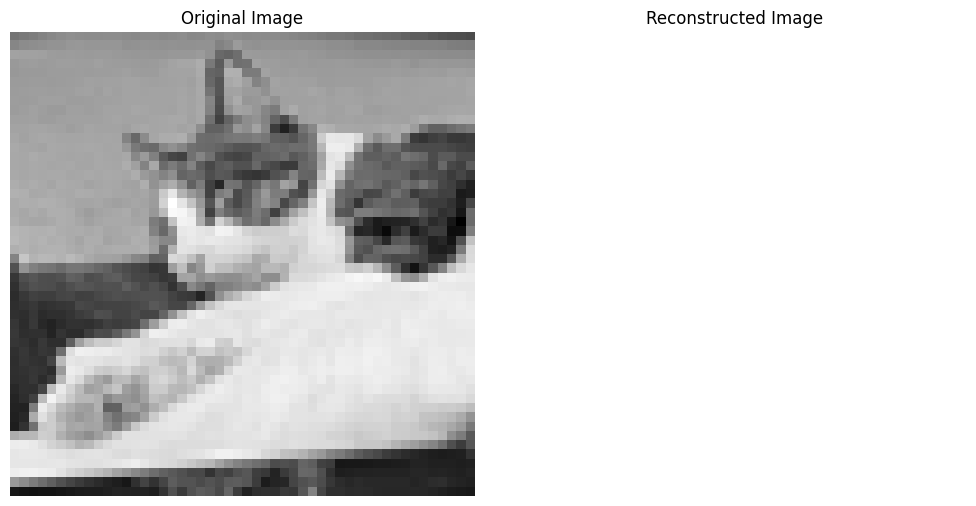

ValueError: operands could not be broadcast together with shapes (50,50) (0,0) 

In [60]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

def image_to_complex_signal(image_path, max_samples=10000):
    """
    Convert an image to a complex signal for transmission, with metadata.
    
    Args:
        image_path: Path to image file
        max_samples: Max samples to limit transmission size
    
    Returns:
        transmit_signal: complex numpy array (metadata + image data)
        image_size: (width, height)
    """
    img = Image.open(image_path).convert('L')
    print(f"Original image size: {img.size}")
    
    # Resize if too big (considering bits → samples)
    total_pixels = img.size[0] * img.size[1]
    max_bits = max_samples * 1  # One bit per sample assumed
    
    if total_pixels * 8 > max_bits:
        scale_factor = np.sqrt(max_bits / (total_pixels * 8))
        new_w = int(img.size[0] * scale_factor)
        new_h = int(img.size[1] * scale_factor)
        img = img.resize((new_w, new_h), Image.Resampling.LANCZOS)
        print(f"Resized image to: {img.size} ({new_w * new_h} pixels)")
    
    image_size = img.size
    
    # Convert to numpy uint8 array
    img_array = np.asarray(img, dtype=np.uint8)
    
    # Flatten and convert to bits
    flat_pixels = img_array.flatten()
    bitstream = np.unpackbits(flat_pixels)
    
    print(f"Total bits to transmit: {len(bitstream)}")
    
    # Map bits 0->-1, 1->+1 for BPSK-like complex baseband signal (real only)
    signal_data = 2 * bitstream.astype(np.float32) - 1
    
    # Metadata (complex numbers) -- 10 samples reserved
    # Encode width and height normalized to 1000, scaled to [-1,1]
    width_norm = image_size[0] / 1000.0
    height_norm = image_size[1] / 1000.0
    num_bits_norm = len(bitstream) / (max_bits)  # fraction of max bits
    
    sync_pattern = [0.9, -0.9, 0.9, -0.9]
    
    metadata = np.array([
        sync_pattern[0] + 1j * sync_pattern[1],
        sync_pattern[2] + 1j * sync_pattern[3],
        width_norm + 1j * height_norm,
        num_bits_norm + 1j * 0,
        0 + 1j * 0,
        0 + 1j * 0,
        0 + 1j * 0,
        0 + 1j * 0,
        0 + 1j * 0,
        0 + 1j * 0
    ], dtype=np.complex64)
    
    # Combine metadata + signal data (real part only, imag = 0)
    transmit_signal = np.concatenate([metadata, signal_data + 0j])
    
    print(f"Transmit signal length: {len(transmit_signal)} (metadata + data)")
    return transmit_signal, image_size

def extract_metadata_from_signal(signal):
    """
    Extract metadata from received signal.
    Returns (width, height), data_start index, estimated bit length.
    """
    sync1 = 0.9 - 1j * 0.9
    sync2 = 0.9 - 1j * 0.9
    
    best_corr = 0
    best_offset = 0
    
    for offset in range(min(15, len(signal) - 2)):
        s1 = signal[offset]
        s2 = signal[offset + 1]
        corr = 1.0 / (1.0 + np.abs(s1 - sync1) + np.abs(s2 - sync2))
        if corr > best_corr:
            best_corr = corr
            best_offset = offset
    
    print(f"Found sync at offset {best_offset} with corr {best_corr:.3f}")
    
    if best_offset + 3 < len(signal):
        dim = signal[best_offset + 2]
        width = int(np.clip(round(np.real(dim) * 1000), 10, 2000))
        height = int(np.clip(round(np.imag(dim) * 1000), 10, 2000))
        
        length_sample = signal[best_offset + 3]
        estimated_fraction = np.real(length_sample)
        
        data_start = best_offset + 10
        print(f"Extracted metadata: width={width}, height={height}, fraction={estimated_fraction:.4f}")
        
        # Estimate bit length (bits transmitted = fraction * max_bits assumed)
        # We’ll assume max_bits = 8 * width * height here (max possible)
        max_bits = 8 * width * height
        estimated_bits = int(np.clip(round(estimated_fraction * max_bits), 0, max_bits))
        
        return (width, height), data_start, estimated_bits
    else:
        print("Not enough samples for metadata extraction")
        return None, 0, len(signal)

def complex_signal_to_image(signal, image_size=None):
    """
    Decode complex signal (real-only bits) back to image.
    """
    orig_len = len(signal)
    
    if image_size is None:
        image_size, data_start, estimated_bits = extract_metadata_from_signal(signal)
        data_signal = signal[data_start:]
    else:
        data_start = 10  # skip metadata if present
        data_signal = signal[data_start:]
        estimated_bits = 8 * image_size[0] * image_size[1]
    
    # Extract bits from real part
    bits = (np.real(data_signal[:estimated_bits]) > 0).astype(np.uint8)
    
    # Pack bits back to bytes, truncate or pad as needed
    n_bytes = (len(bits) + 7) // 8
    if len(bits) % 8 != 0:
        bits = np.pad(bits, (0, 8 - (len(bits) % 8)), constant_values=0)
    
    byte_data = np.packbits(bits)[:n_bytes]
    
    # Reshape to image
    try:
        img_array = byte_data.reshape((image_size[1], image_size[0]))
    except:
        # fallback to square if reshape fails
        side = int(np.sqrt(len(byte_data)))
        img_array = byte_data[:side*side].reshape((side, side))
        print(f"Reshaping fallback to {side}x{side}")
    
    return Image.fromarray(img_array, mode='L')


# -------------------------
# Example usage
# -------------------------
image_path = "../files/image.jpg"
max_samples = 20000

transmit_signal, img_size = image_to_complex_signal(image_path, max_samples=max_samples)

print(f"Original image size: {img_size}, transmit signal length: {len(transmit_signal)}")

# Simulate transmission (identity channel)
receive_signal = system.receive_signal()

# Decode received signal
reconstructed_img = complex_signal_to_image(receive_signal)

# Show results
original_img = Image.open(image_path).convert('L')
if original_img.size != img_size:
    original_img = original_img.resize(img_size, Image.Resampling.LANCZOS)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(original_img, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(reconstructed_img, cmap='gray')
plt.title("Reconstructed Image")
plt.axis('off')

plt.tight_layout()
plt.show()

# Compute quality metrics
orig_arr = np.array(original_img)
recon_arr = np.array(reconstructed_img)
mse = np.mean((orig_arr - recon_arr) ** 2)
psnr = 20 * np.log10(255.0 / np.sqrt(mse)) if mse > 0 else float('inf')
print(f"MSE: {mse:.2f}, PSNR: {psnr:.2f} dB")


In [54]:
def image_to_bits(image_path, max_bits=20000):
    img = Image.open(image_path).convert('L')
    print(f"Original image size: {img.size}")
    img_array = np.asarray(img, dtype=np.uint8)
    flat_pixels = img_array.flatten()
    bitstream = np.unpackbits(flat_pixels)
    if len(bitstream) > max_bits:
        scale_factor = np.sqrt(max_bits / len(bitstream))
        new_w = int(img.size[0] * scale_factor)
        new_h = int(img.size[1] * scale_factor)
        img = img.resize((new_w, new_h), Image.Resampling.LANCZOS)
        print(f"Resized to {img.size}")
        img_array = np.asarray(img, dtype=np.uint8)
        flat_pixels = img_array.flatten()
        bitstream = np.unpackbits(flat_pixels)
    return bitstream, img.size

def bits_to_signal(bitstream, img_size, max_bits=20000):
    signal_data = 2 * bitstream.astype(np.float32) - 1
    
    # img info
    width_bits = int_to_bits(img_size[0], 16)
    height_bits = int_to_bits(img_size[1], 16)
    imginfo = np.concatenate([width_bits, height_bits])
    
    infoSignal = 2 * imginfo.astype(np.float32) - 1 
    transmit_signal = np.concatenate([infoSignal, signal_data])
    
    return transmit_signal.astype(np.complex64)

def signal_to_bits(signal, image_size=None, max_bits=20000):
    first32 = np.real(signal[:32])
    infobits = (first32 > 0).astype(int)
    
    width_bits = infobits[:16]
    height_bits = infobits[16:32]
    
    detected_width = bits_to_int(width_bits)
    detected_height = bits_to_int(height_bits)
    
    print(str(detected_width))
    print(str(detected_height))

    image_size = (detected_width, detected_height)
    
    expected_bits = 8 * image_size[0] * image_size[1]
    
    data_signal = signal[32:]
    
    bits = (np.real(data_signal[:expected_bits]) > 0).astype(np.uint8)
    
    return bits

def bits_to_image(bits, image_size):
    if len(bits) % 8 != 0:
        bits = np.pad(bits, (0, 8 - (len(bits) % 8)), constant_values=0)
    byte_data = np.packbits(bits)
    expected_bytes = image_size[0] * image_size[1]
    if len(byte_data) < expected_bytes:
        byte_data = np.pad(byte_data, (0, expected_bytes - len(byte_data)), constant_values=0)
        print(f"Padded byte data from {len(byte_data)} to {expected_bytes}")
    elif len(byte_data) > expected_bytes:
        byte_data = byte_data[:expected_bytes]
        print(f"Trimmed byte data to {expected_bytes}")
    try:
        img_array = byte_data.reshape((image_size[1], image_size[0]))
    except Exception as e:
        print(f"Reshape error: {e}")
        side = int(np.sqrt(len(byte_data)))
        img_array = byte_data[:side*side].reshape((side, side))
        print(f"Fallback reshape to {side}x{side}")
    return Image.fromarray(img_array, mode='L')

Original image size: (200, 200)
Resized to (44, 44)
Encoded signal length: 15520
44
44
detected size:(44, 44)


C:\Users\mihir\AppData\Local\Temp\ipykernel_67060\636062917.py:72: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(img_array, mode='L')


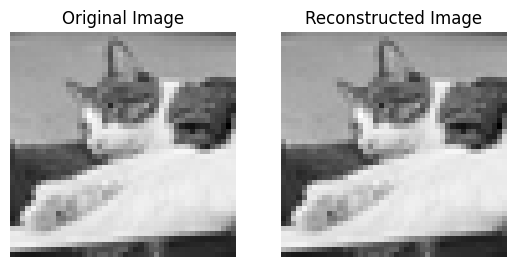

In [58]:
image_path = "../files/image.jpg"

bitstream, original_size = image_to_bits(image_path, max_bits=16000)
transmit_signal = bits_to_signal(bitstream, original_size, max_bits=16000)

print(f"Encoded signal length: {len(transmit_signal)}")

# ---- SDR TRANSMIT ----
# system.transmit_signal(transmit_signal) 

# # ---- SDR RECEIVE ----
# receive_signal = system.receive_signal() 

# For testing, simulate perfect channel:
receive_signal = transmit_signal.copy()

received_bits = signal_to_bits(receive_signal)

metadata_samples = np.real(receive_signal[:32])
metadata_bits = (metadata_samples > 0).astype(int)
width = bits_to_int(metadata_bits[:16])
height = bits_to_int(metadata_bits[16:32])
detected_size = (width, height)

print("detected size:" + str(detected_size))

reconstructed_image = bits_to_image(received_bits, detected_size)

# Show original and reconstructed images
original_image = Image.open(image_path).convert('L')
if original_image.size != original_size:
    original_image = original_image.resize(original_size, Image.Resampling.LANCZOS)

plt.subplot(1,2,1)
plt.imshow(original_image, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(reconstructed_image, cmap='gray')
plt.title("Reconstructed Image")
plt.axis('off')

plt.show()


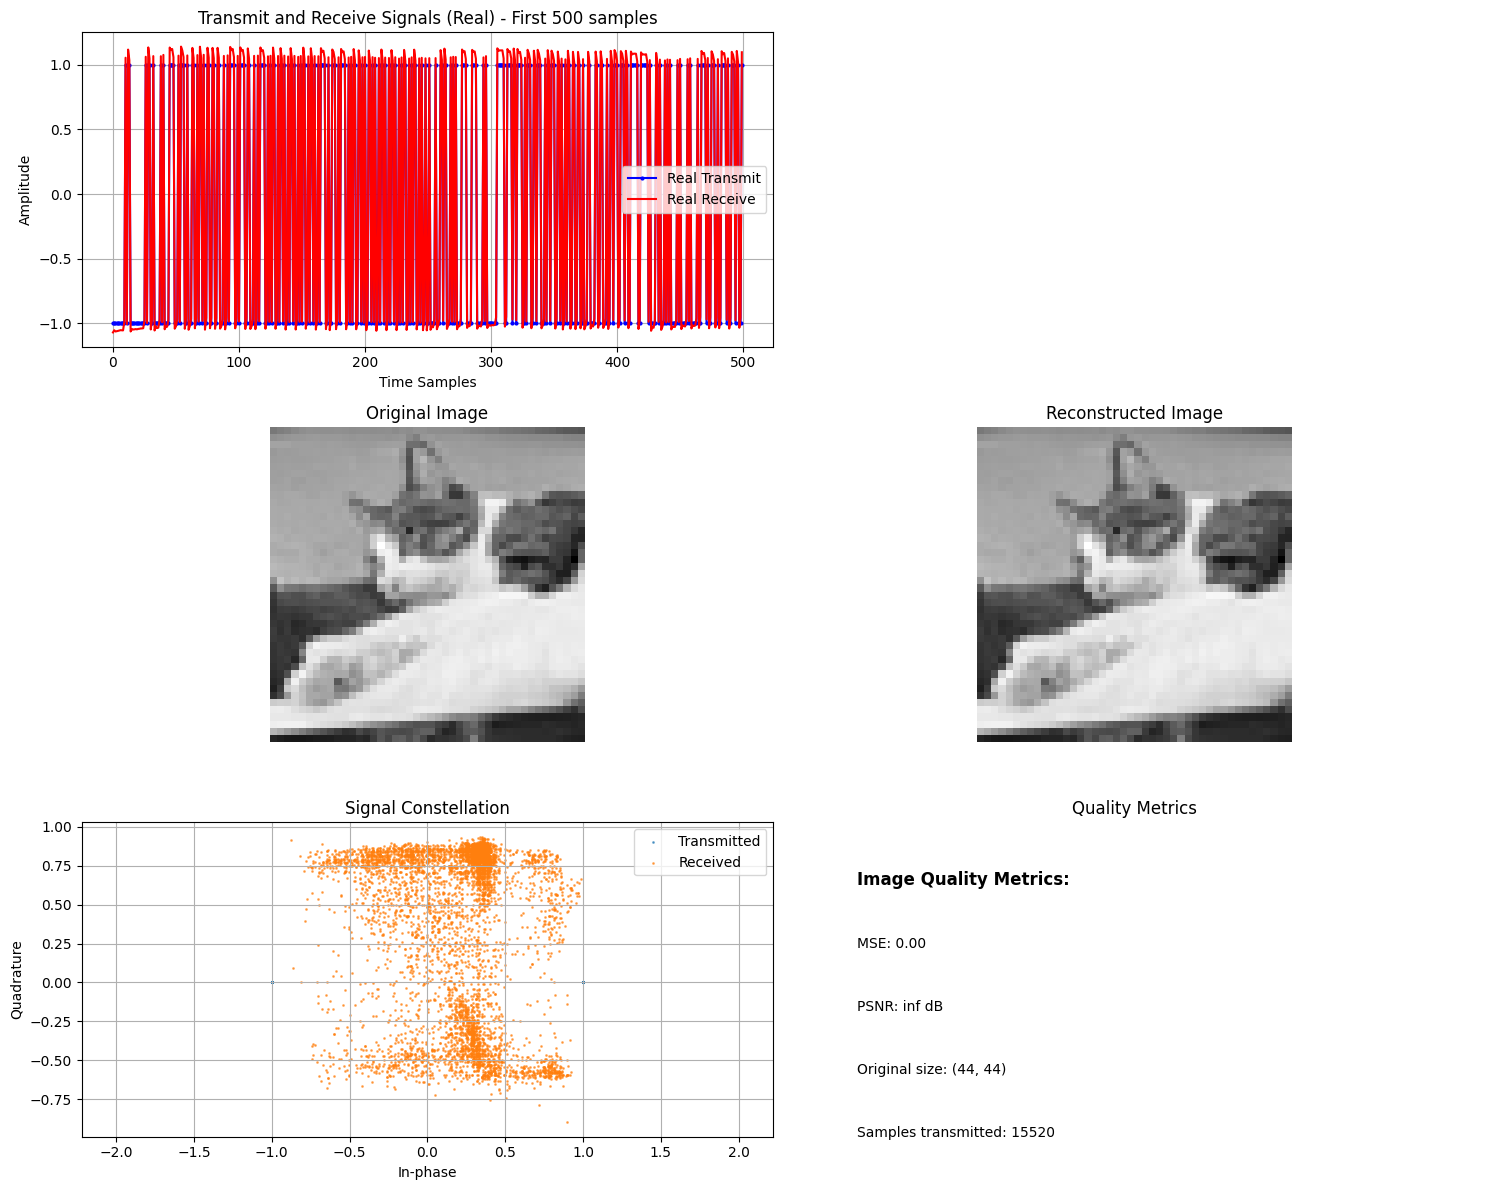

In [39]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

# Assuming you already have these variables from your transmission process:
# transmit_signal, receive_signal, receive_symbols, original_size, original_image, reconstructed_image, sps

plt.figure(figsize=(15, 12))

# Plot signal comparison - Real part
plt.subplot(3, 2, 1)
plt.plot(np.real(transmit_signal[:500]), color="blue", marker="o", markersize=2, label="Real Transmit")
plt.plot(np.real(receive_signal[:500]), color="red", label="Real Receive")
plt.title("Transmit and Receive Signals (Real) - First 500 samples")
plt.xlabel("Time Samples")
plt.ylabel("Amplitude")
plt.grid(True)
plt.legend()

# Original image display
plt.subplot(3, 2, 3)
plt.imshow(original_image, cmap='gray')
plt.title("Original Image")
plt.axis('off')

# Reconstructed image display
plt.subplot(3, 2, 4)
plt.imshow(reconstructed_image, cmap='gray')
plt.title("Reconstructed Image")
plt.axis('off')

# Signal constellation plot
plt.subplot(3, 2, 5)
plt.scatter(np.real(transmit_signal), np.imag(transmit_signal), alpha=0.6, s=1, label='Transmitted')
plt.scatter(np.real(receive_symbols), np.imag(receive_symbols), alpha=0.6, s=1, label='Received')
plt.xlabel('In-phase')
plt.ylabel('Quadrature')
plt.title('Signal Constellation')
plt.grid(True)
plt.legend()
plt.axis('equal')

# Image quality metrics
plt.subplot(3, 2, 6)
original_array = np.array(original_image)
reconstructed_array = np.array(reconstructed_image)

# Calculate Mean Squared Error (MSE)
mse = np.mean((original_array - reconstructed_array) ** 2)

# Calculate Peak Signal-to-Noise Ratio (PSNR)
if mse > 0:
    psnr = 20 * np.log10(255.0 / np.sqrt(mse))
else:
    psnr = float('inf')

plt.text(0.1, 0.8, "Image Quality Metrics:", fontsize=12, fontweight='bold')
plt.text(0.1, 0.6, f"MSE: {mse:.2f}", fontsize=10)
plt.text(0.1, 0.4, f"PSNR: {psnr:.2f} dB", fontsize=10)
plt.text(0.1, 0.2, f"Original size: {original_size}", fontsize=10)
plt.text(0.1, 0.0, f"Samples transmitted: {len(transmit_signal)}", fontsize=10)
plt.axis('off')
plt.title('Quality Metrics')

plt.tight_layout()
plt.show()
